<a href="https://colab.research.google.com/github/Kavin-Prakash-T/ds-hackathon/blob/main/DS_Hack_Q1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

# Plot settings
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [68]:
df = pd.read_csv(
    "logistics_delivery_dataset.csv"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [69]:
df.head(10)

,Shipment_ID,Delivery_Partner,Region,Promised_Date,Actual_Date,Delivery_Cost,Customer_Rating
0,SHP00001,Ecom Express,Hyderabad,2025-04-06,2025-04-06,91.42,4.1
1,SHP00002,DHL,Madurai,2025-07-19,2025-07-20,136.51,4.0
2,SHP00003,Shadowfax,Hyderabad,2025-09-04,2025-09-06,88.21,4.4
3,SHP00004,DTDC,Kochi,2025-03-13,2025-03-10,104.69,4.6
4,SHP00005,Delhivery,Delhi,2025-11-14,2025-11-18,89.06,3.6
5,SHP00006,Delhivery,Bangalore,2025-07-04,2025-07-07,77.89,4.2
6,SHP00007,Delhivery,Delhi,2025-01-06,2025-01-06,96.71,4.9
7,SHP00008,Ekart,Mumbai,2025-07-25,2025-07-23,82.01,4.8
8,SHP00009,DTDC,Bangalore,2025-02-01,2025-02-02,98.23,3.9
9,SHP00010,Shadowfax,Mumbai,2025-04-09,2025-04-10,52.16,4.0


In [70]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 2000
Number of columns: 7


In [71]:
print("Columns in dataset:")

for column in df.columns:
    print("-", column)

Columns in dataset:
- Shipment_ID
- Delivery_Partner
- Region
- Promised_Date
- Actual_Date
- Delivery_Cost
- Customer_Rating


In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Shipment_ID       2000 non-null   object 
 1   Delivery_Partner  2000 non-null   object 
 2   Region            2000 non-null   object 
 3   Promised_Date     2000 non-null   object 
 4   Actual_Date       2000 non-null   object 
 5   Delivery_Cost     2000 non-null   float64
 6   Customer_Rating   2000 non-null   float64
dtypes: float64(2), object(5)
memory usage: 109.5+ KB


In [73]:
df.describe()

,Delivery_Cost,Customer_Rating
count,2000.000000,2000.00000
mean,91.062030,4.23165
std,21.716272,0.44640
min,50.000000,2.30000
25%,75.397500,3.90000
50%,87.185000,4.30000
75%,102.240000,4.50000
max,165.730000,5.00000


In [74]:
print("Missing values in each column:\n")

print(df.isnull().sum())

Missing values in each column:

Shipment_ID         0
Delivery_Partner    0
Region              0
Promised_Date       0
Actual_Date         0
Delivery_Cost       0
Customer_Rating     0
dtype: int64


In [75]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

print(
    "Duplicate Shipment IDs:",
    df["Shipment_ID"].duplicated().sum()
)

Duplicate rows: 0
Duplicate Shipment IDs: 0


In [76]:
df["Promised_Date"] = pd.to_datetime(
    df["Promised_Date"],
    errors="coerce"
)

df["Actual_Date"] = pd.to_datetime(
    df["Actual_Date"],
    errors="coerce"
)

print("Date columns converted successfully.")

Date columns converted successfully.


In [77]:
print(
    "Invalid Promised Dates:",
    df["Promised_Date"].isna().sum()
)

print(
    "Invalid Actual Dates:",
    df["Actual_Date"].isna().sum()
)

Invalid Promised Dates: 0
Invalid Actual Dates: 0


In [78]:
print("Minimum delivery cost:",
      df["Delivery_Cost"].min())

print("Maximum delivery cost:",
      df["Delivery_Cost"].max())

print(
    "Invalid/negative costs:",
    (df["Delivery_Cost"] < 0).sum()
)

Minimum delivery cost: 50.0
Maximum delivery cost: 165.73
Invalid/negative costs: 0


In [79]:
print("Minimum rating:",
      df["Customer_Rating"].min())

print("Maximum rating:",
      df["Customer_Rating"].max())

invalid_ratings = (
    (df["Customer_Rating"] < 1) |
    (df["Customer_Rating"] > 5)
).sum()

print(
    "Invalid ratings:",
    invalid_ratings
)

Minimum rating: 2.3
Maximum rating: 5.0
Invalid ratings: 0


In [80]:
df["Delivery_Delay"] = (
    df["Actual_Date"] -
    df["Promised_Date"]
).dt.days

df[
    [
        "Shipment_ID",
        "Promised_Date",
        "Actual_Date",
        "Delivery_Delay"
    ]
].head(10)

,Shipment_ID,Promised_Date,Actual_Date,Delivery_Delay
0,SHP00001,2025-04-06,2025-04-06,0
1,SHP00002,2025-07-19,2025-07-20,1
2,SHP00003,2025-09-04,2025-09-06,2
3,SHP00004,2025-03-13,2025-03-10,-3
4,SHP00005,2025-11-14,2025-11-18,4
5,SHP00006,2025-07-04,2025-07-07,3
6,SHP00007,2025-01-06,2025-01-06,0
7,SHP00008,2025-07-25,2025-07-23,-2
8,SHP00009,2025-02-01,2025-02-02,1
9,SHP00010,2025-04-09,2025-04-10,1


In [81]:
df["On_Time"] = np.where(
    df["Actual_Date"] <= df["Promised_Date"],
    1,
    0
)

df["Delivery_Status"] = df["On_Time"].map({
    1: "On Time",
    0: "Late"
})

df[
    [
        "Shipment_ID",
        "Delivery_Delay",
        "On_Time",
        "Delivery_Status"
    ]
].head(10)

,Shipment_ID,Delivery_Delay,On_Time,Delivery_Status
0,SHP00001,0,1,On Time
1,SHP00002,1,0,Late
2,SHP00003,2,0,Late
3,SHP00004,-3,1,On Time
4,SHP00005,4,0,Late
5,SHP00006,3,0,Late
6,SHP00007,0,1,On Time
7,SHP00008,-2,1,On Time
8,SHP00009,1,0,Late
9,SHP00010,1,0,Late


In [82]:
overall_on_time = (
    df["On_Time"].mean() * 100
)

print(
    f"Overall On-Time Delivery: "
    f"{overall_on_time:.2f}%"
)

Overall On-Time Delivery: 51.65%


In [83]:
status_count = df[
    "Delivery_Status"
].value_counts()

print(status_count)

Delivery_Status
On Time    1033
Late        967
Name: count, dtype: int64


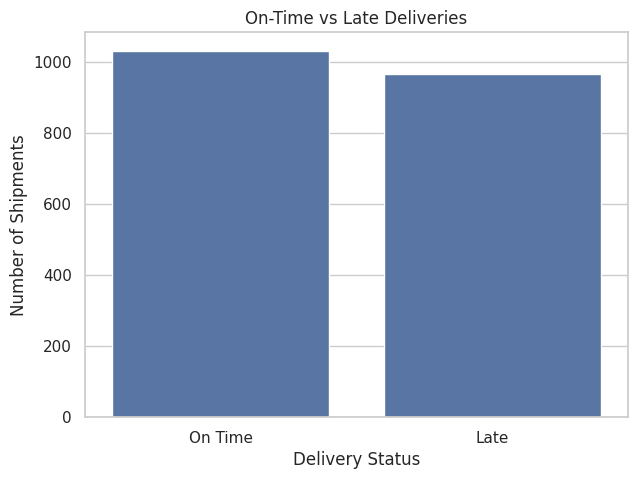

In [84]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Delivery_Status"
)

plt.title("On-Time vs Late Deliveries")
plt.xlabel("Delivery Status")
plt.ylabel("Number of Shipments")

plt.show()

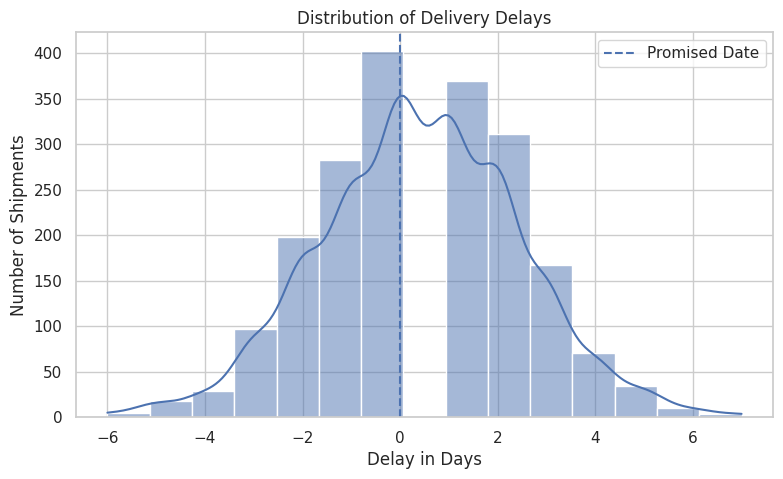

In [85]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["Delivery_Delay"],
    bins=15,
    kde=True
)

plt.axvline(
    0,
    linestyle="--",
    label="Promised Date"
)

plt.title("Distribution of Delivery Delays")
plt.xlabel("Delay in Days")
plt.ylabel("Number of Shipments")

plt.legend()

plt.show()

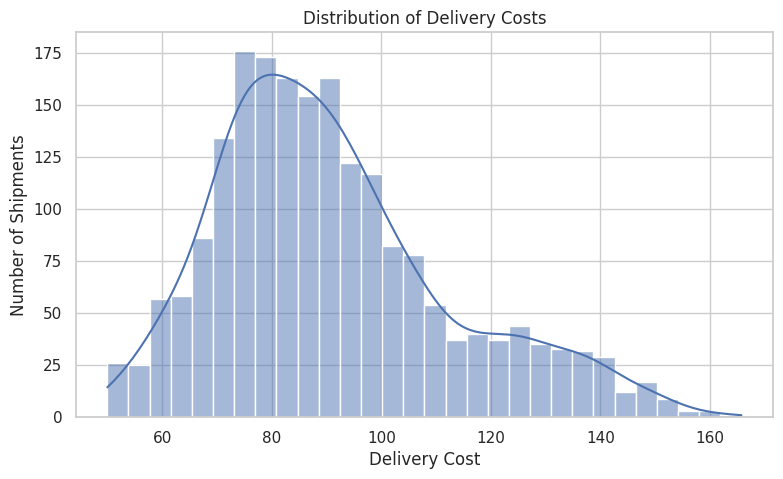

In [86]:
plt.figure(figsize=(9, 5))

sns.histplot(
    df["Delivery_Cost"],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Costs")
plt.xlabel("Delivery Cost")
plt.ylabel("Number of Shipments")

plt.show()

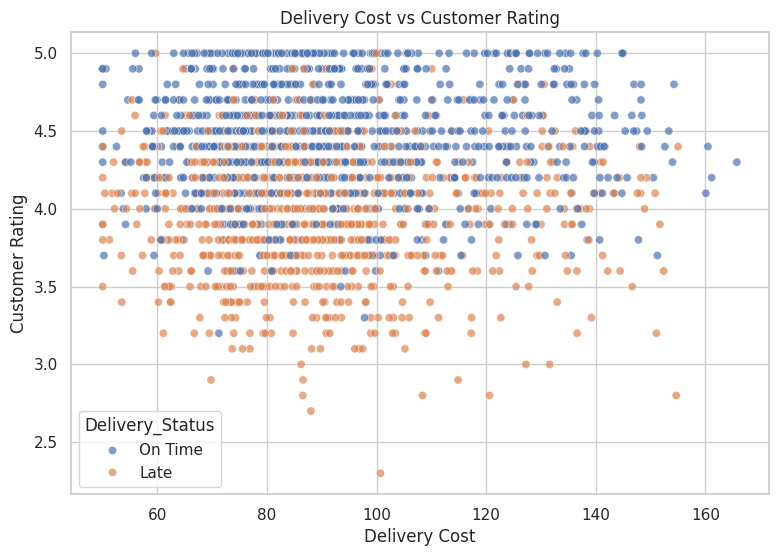

In [87]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Delivery_Cost",
    y="Customer_Rating",
    hue="Delivery_Status",
    alpha=0.7
)

plt.title(
    "Delivery Cost vs Customer Rating"
)

plt.xlabel("Delivery Cost")
plt.ylabel("Customer Rating")

plt.show()

In [88]:
partner_summary = df.groupby(
    "Delivery_Partner"
).agg(
    Shipments=("Shipment_ID", "count"),
    On_Time_Percentage=("On_Time", "mean"),
    Average_Cost=("Delivery_Cost", "mean"),
    Average_Rating=("Customer_Rating", "mean"),
    Average_Delay=("Delivery_Delay", "mean")
).reset_index()

partner_summary[
    "On_Time_Percentage"
] *= 100

partner_summary.round(2)

,Delivery_Partner,Shipments,On_Time_Percentage,Average_Cost,Average_Rating,Average_Delay
0,Blue Dart,255,62.35,114.41,4.25,0.03
1,DHL,180,61.11,134.51,4.31,-0.16
2,DTDC,266,48.12,89.74,4.20,0.58
3,Delhivery,390,54.62,86.05,4.24,0.19
4,Ecom Express,248,41.94,74.30,4.18,0.88
5,Ekart,198,46.46,81.63,4.26,0.62
6,Shadowfax,217,48.39,78.07,4.23,0.62
7,XpressBees,246,49.59,80.40,4.20,0.59


In [89]:
partner_summary.sort_values(
    "On_Time_Percentage",
    ascending=False
).round(2)

,Delivery_Partner,Shipments,On_Time_Percentage,Average_Cost,Average_Rating,Average_Delay
0,Blue Dart,255,62.35,114.41,4.25,0.03
1,DHL,180,61.11,134.51,4.31,-0.16
3,Delhivery,390,54.62,86.05,4.24,0.19
7,XpressBees,246,49.59,80.40,4.20,0.59
6,Shadowfax,217,48.39,78.07,4.23,0.62
2,DTDC,266,48.12,89.74,4.20,0.58
5,Ekart,198,46.46,81.63,4.26,0.62
4,Ecom Express,248,41.94,74.30,4.18,0.88


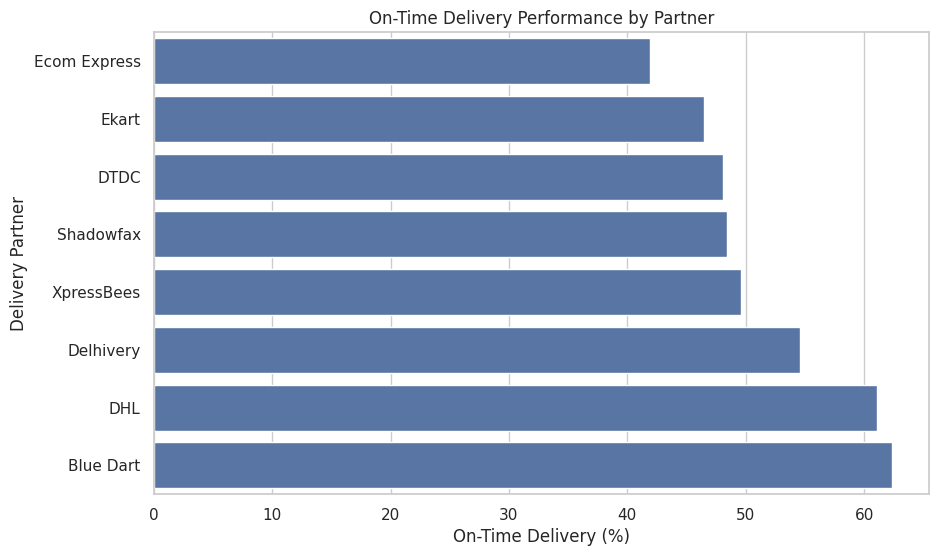

In [90]:
partner_plot = partner_summary.sort_values(
    "On_Time_Percentage",
    ascending=True
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=partner_plot,
    x="On_Time_Percentage",
    y="Delivery_Partner"
)

plt.title(
    "On-Time Delivery Performance by Partner"
)

plt.xlabel("On-Time Delivery (%)")
plt.ylabel("Delivery Partner")

plt.show()

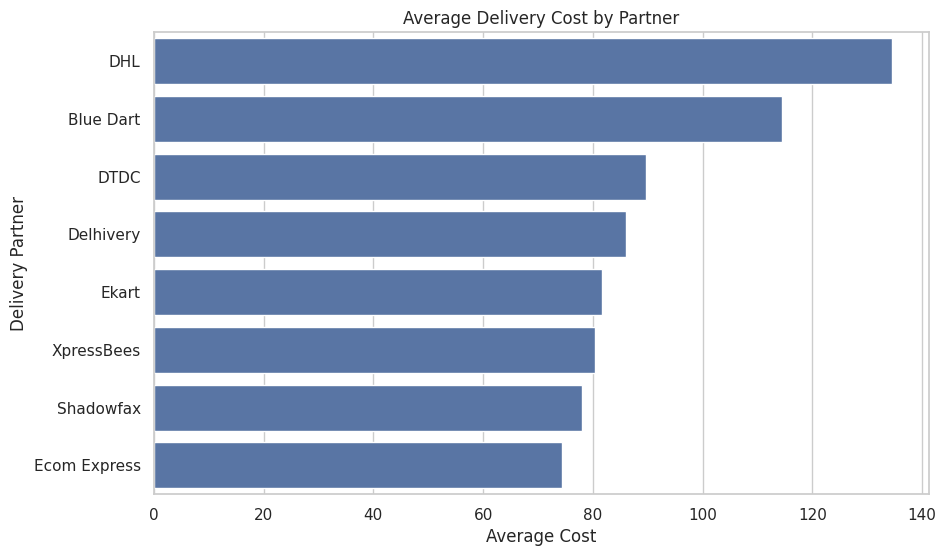

In [91]:
partner_cost = partner_summary.sort_values(
    "Average_Cost",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=partner_cost,
    x="Average_Cost",
    y="Delivery_Partner"
)

plt.title(
    "Average Delivery Cost by Partner"
)

plt.xlabel("Average Cost")
plt.ylabel("Delivery Partner")

plt.show()

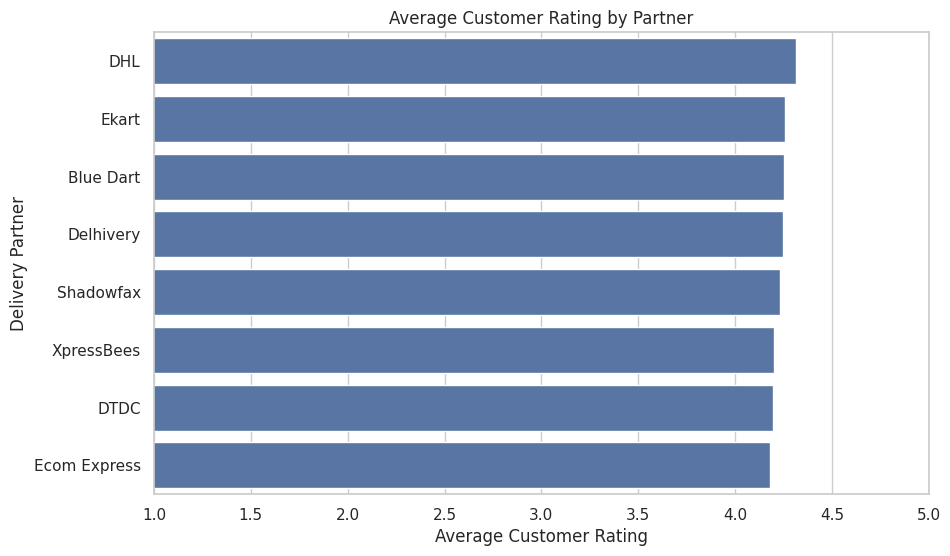

In [92]:
partner_rating = partner_summary.sort_values(
    "Average_Rating",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=partner_rating,
    x="Average_Rating",
    y="Delivery_Partner"
)

plt.title(
    "Average Customer Rating by Partner"
)

plt.xlabel("Average Customer Rating")
plt.ylabel("Delivery Partner")

plt.xlim(1, 5)

plt.show()

In [93]:
regional_summary = df.groupby(
    "Region"
).agg(
    Shipments=("Shipment_ID", "count"),
    On_Time_Percentage=("On_Time", "mean"),
    Average_Cost=("Delivery_Cost", "mean"),
    Average_Rating=("Customer_Rating", "mean"),
    Average_Delay=("Delivery_Delay", "mean")
).reset_index()

regional_summary[
    "On_Time_Percentage"
] *= 100

regional_summary.round(2)

,Region,Shipments,On_Time_Percentage,Average_Cost,Average_Rating,Average_Delay
0,Bangalore,216,57.41,90.54,4.23,0.33
1,Chennai,210,51.90,92.87,4.24,0.34
2,Coimbatore,185,51.35,92.09,4.22,0.54
3,Delhi,184,57.61,89.65,4.27,0.21
4,Hyderabad,188,52.13,92.89,4.25,0.40
5,Kochi,211,45.50,89.81,4.19,0.55
6,Madurai,211,49.29,90.01,4.21,0.43
7,Mumbai,203,49.26,90.70,4.20,0.51
8,Salem,195,47.69,91.29,4.23,0.49
9,Tiruchirappalli,197,54.82,90.92,4.28,0.33


In [94]:
regional_summary.sort_values(
    "On_Time_Percentage",
    ascending=False
).round(2)

,Region,Shipments,On_Time_Percentage,Average_Cost,Average_Rating,Average_Delay
3,Delhi,184,57.61,89.65,4.27,0.21
0,Bangalore,216,57.41,90.54,4.23,0.33
9,Tiruchirappalli,197,54.82,90.92,4.28,0.33
4,Hyderabad,188,52.13,92.89,4.25,0.40
1,Chennai,210,51.90,92.87,4.24,0.34
2,Coimbatore,185,51.35,92.09,4.22,0.54
6,Madurai,211,49.29,90.01,4.21,0.43
7,Mumbai,203,49.26,90.70,4.20,0.51
8,Salem,195,47.69,91.29,4.23,0.49
5,Kochi,211,45.50,89.81,4.19,0.55


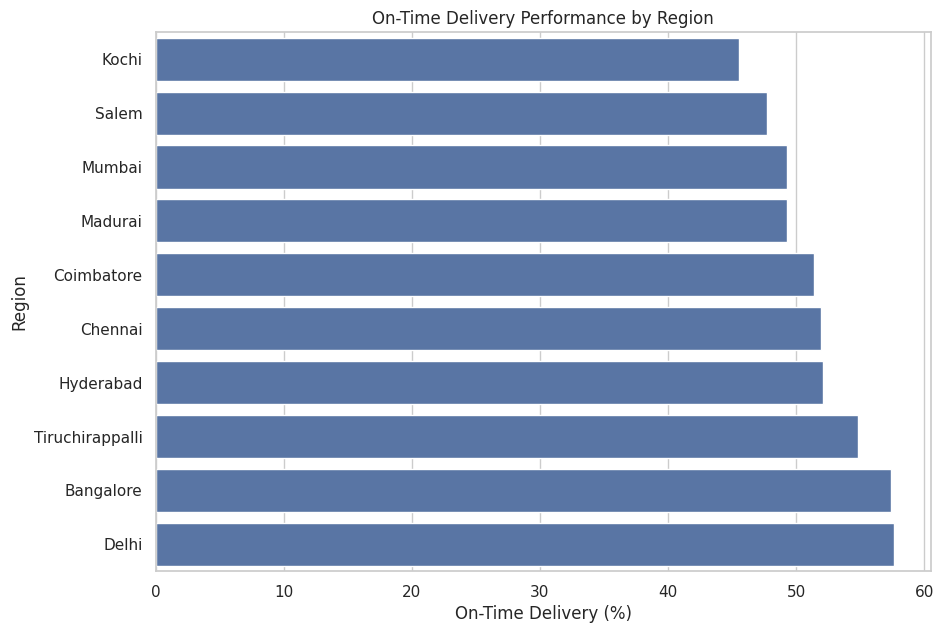

In [95]:
region_plot = regional_summary.sort_values(
    "On_Time_Percentage",
    ascending=True
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=region_plot,
    x="On_Time_Percentage",
    y="Region"
)

plt.title(
    "On-Time Delivery Performance by Region"
)

plt.xlabel("On-Time Delivery (%)")
plt.ylabel("Region")

plt.show()

In [96]:
partner_region = pd.pivot_table(
    df,
    values="On_Time",
    index="Region",
    columns="Delivery_Partner",
    aggfunc="mean"
)

partner_region_percentage = (
    partner_region * 100
)

partner_region_percentage.round(1)

Delivery_Partner,Blue Dart,DHL,DTDC,Delhivery,Ecom Express,Ekart,Shadowfax,XpressBees
Region,,,,,,,,
Bangalore,78.8,71.4,44.8,43.5,50.0,44.4,65.4,66.7
Chennai,75.9,54.5,42.4,56.1,43.5,47.1,45.5,43.5
Coimbatore,53.8,55.0,60.0,62.5,31.8,36.4,40.0,57.9
Delhi,73.9,64.3,57.9,69.8,45.0,42.9,62.5,38.1
Hyderabad,58.3,57.1,55.6,61.1,46.4,36.4,36.4,52.6
Kochi,44.0,53.3,63.0,44.2,33.3,38.7,46.7,45.2
Madurai,48.0,66.7,42.9,48.6,53.8,60.0,31.8,44.8
Mumbai,52.2,53.3,50.0,51.2,42.3,57.1,43.5,45.8
Salem,57.7,58.8,23.1,53.1,33.3,64.3,55.0,50.0


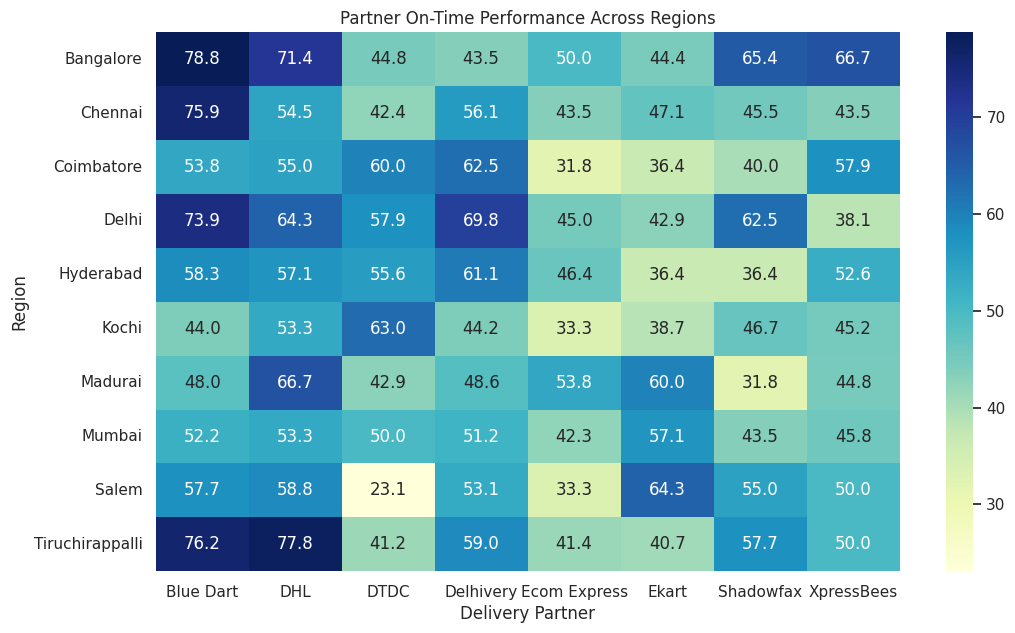

In [97]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    partner_region_percentage,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title(
    "Partner On-Time Performance Across Regions"
)

plt.xlabel("Delivery Partner")
plt.ylabel("Region")

plt.show()

In [98]:
partner_consistency = df.groupby(
    ["Delivery_Partner", "Region"]
)["On_Time"].mean().reset_index()

consistency_summary = partner_consistency.groupby(
    "Delivery_Partner"
)["On_Time"].agg(
    Mean_On_Time="mean",
    Std_Deviation="std"
).reset_index()

consistency_summary[
    "Mean_On_Time"
] *= 100

consistency_summary.round(2)

,Delivery_Partner,Mean_On_Time,Std_Deviation
0,Blue Dart,61.88,0.13
1,DHL,61.23,0.08
2,DTDC,48.08,0.12
3,Delhivery,54.91,0.08
4,Ecom Express,42.09,0.07
5,Ekart,46.80,0.10
6,Shadowfax,48.44,0.11
7,XpressBees,49.46,0.08


In [99]:
delay_partner = df.groupby(
    "Delivery_Partner"
)["Delivery_Delay"].mean().sort_values()

delay_partner.round(2)

,Delivery_Delay
Delivery_Partner,
DHL,-0.16
Blue Dart,0.03
Delhivery,0.19
DTDC,0.58
XpressBees,0.59
Shadowfax,0.62
Ekart,0.62
Ecom Express,0.88


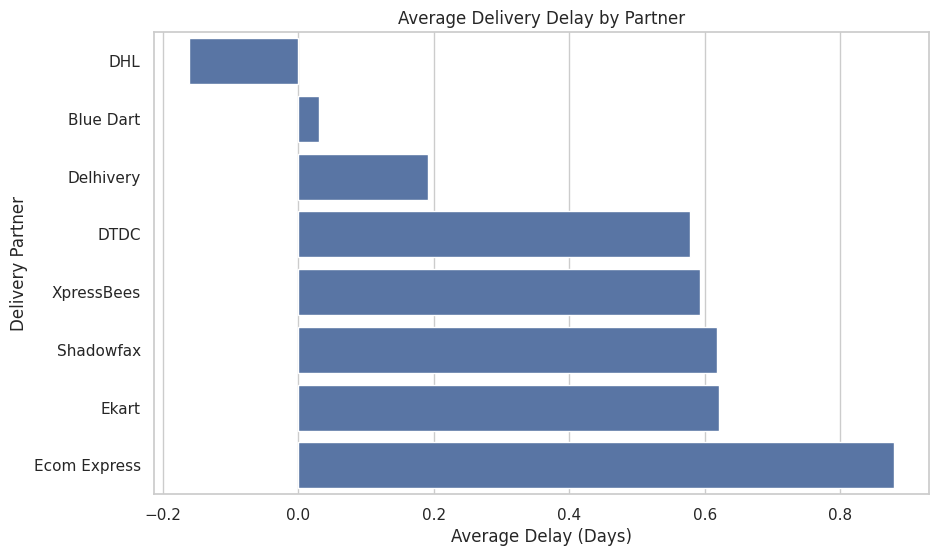

In [100]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=delay_partner.values,
    y=delay_partner.index
)

plt.title(
    "Average Delivery Delay by Partner"
)

plt.xlabel("Average Delay (Days)")
plt.ylabel("Delivery Partner")

plt.show()

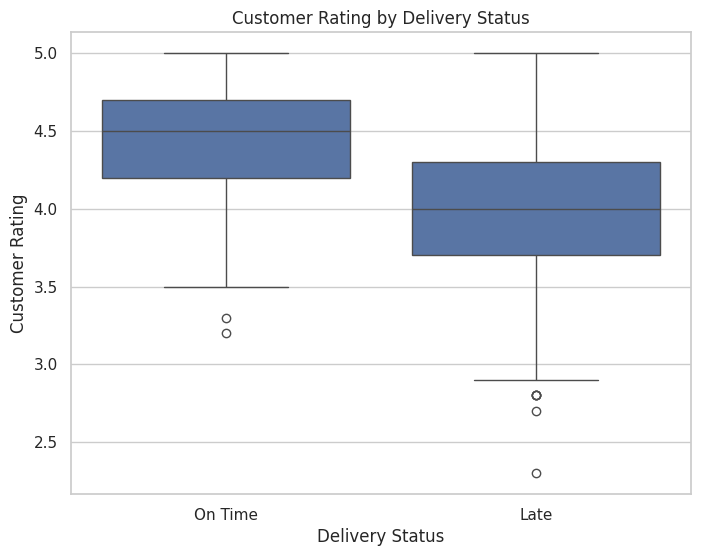

In [101]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="Delivery_Status",
    y="Customer_Rating"
)

plt.title(
    "Customer Rating by Delivery Status"
)

plt.xlabel("Delivery Status")
plt.ylabel("Customer Rating")

plt.show()

In [102]:
dashboard = df.groupby(
    "Delivery_Partner"
).agg(
    Shipments=("Shipment_ID", "count"),
    On_Time_Percentage=("On_Time", "mean"),
    Average_Cost=("Delivery_Cost", "mean"),
    Average_Rating=("Customer_Rating", "mean"),
    Average_Delay=("Delivery_Delay", "mean")
).reset_index()

dashboard["On_Time_Percentage"] *= 100

dashboard.round(2)

,Delivery_Partner,Shipments,On_Time_Percentage,Average_Cost,Average_Rating,Average_Delay
0,Blue Dart,255,62.35,114.41,4.25,0.03
1,DHL,180,61.11,134.51,4.31,-0.16
2,DTDC,266,48.12,89.74,4.20,0.58
3,Delhivery,390,54.62,86.05,4.24,0.19
4,Ecom Express,248,41.94,74.30,4.18,0.88
5,Ekart,198,46.46,81.63,4.26,0.62
6,Shadowfax,217,48.39,78.07,4.23,0.62
7,XpressBees,246,49.59,80.40,4.20,0.59


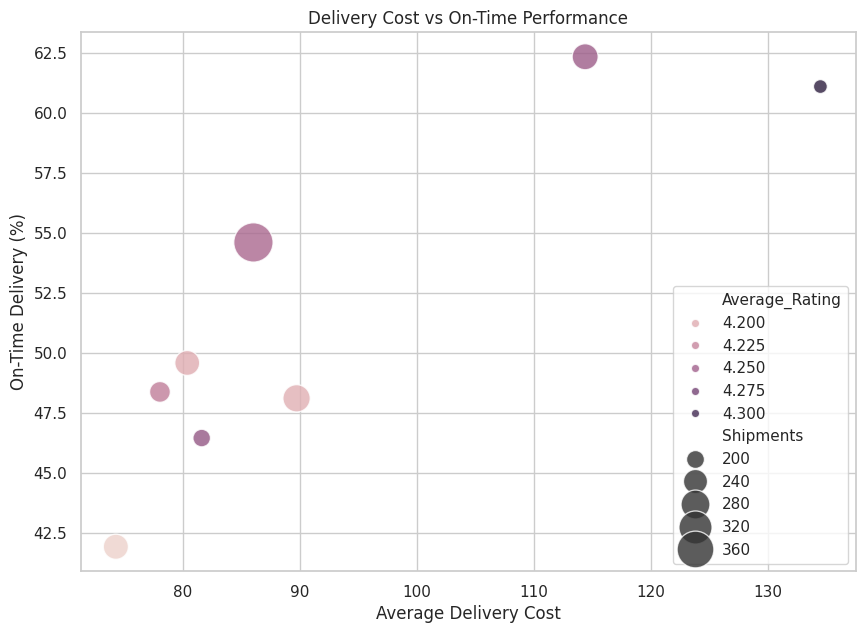

In [103]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=dashboard,
    x="Average_Cost",
    y="On_Time_Percentage",
    size="Shipments",
    hue="Average_Rating",
    sizes=(100, 800),
    alpha=0.8
)

plt.title(
    "Delivery Cost vs On-Time Performance"
)

plt.xlabel("Average Delivery Cost")
plt.ylabel("On-Time Delivery (%)")

plt.show()

In [104]:
final_comparison = dashboard[
    [
        "Delivery_Partner",
        "Shipments",
        "On_Time_Percentage",
        "Average_Cost",
        "Average_Rating",
        "Average_Delay"
    ]
].copy()

final_comparison = final_comparison.sort_values(
    "On_Time_Percentage",
    ascending=False
)

final_comparison.round(2)

,Delivery_Partner,Shipments,On_Time_Percentage,Average_Cost,Average_Rating,Average_Delay
0,Blue Dart,255,62.35,114.41,4.25,0.03
1,DHL,180,61.11,134.51,4.31,-0.16
3,Delhivery,390,54.62,86.05,4.24,0.19
7,XpressBees,246,49.59,80.40,4.20,0.59
6,Shadowfax,217,48.39,78.07,4.23,0.62
2,DTDC,266,48.12,89.74,4.20,0.58
5,Ekart,198,46.46,81.63,4.26,0.62
4,Ecom Express,248,41.94,74.30,4.18,0.88


In [105]:
model_data = df[
    [
        "Delivery_Partner",
        "Region",
        "Delivery_Cost",
        "On_Time"
    ]
].copy()

model_data.head()

,Delivery_Partner,Region,Delivery_Cost,On_Time
0,Ecom Express,Hyderabad,91.42,1
1,DHL,Madurai,136.51,0
2,Shadowfax,Hyderabad,88.21,0
3,DTDC,Kochi,104.69,1
4,Delhivery,Delhi,89.06,0


In [106]:
X = model_data[
    [
        "Delivery_Partner",
        "Region",
        "Delivery_Cost"
    ]
]

y = model_data["On_Time"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print("On_Time")

Features:
['Delivery_Partner', 'Region', 'Delivery_Cost']

Target:
On_Time


In [107]:
categorical_features = [
    "Delivery_Partner",
    "Region"
]

numerical_features = [
    "Delivery_Cost"
]

In [108]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [109]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 1600
Testing samples: 400


In [110]:
decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    random_state=42
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", decision_tree)
    ]
)

print("Decision Tree created successfully!")

Decision Tree created successfully!


In [111]:
model.fit(
    X_train,
    y_train
)

print(
    "Decision Tree trained successfully!"
)

Decision Tree trained successfully!


In [112]:
y_pred = model.predict(
    X_test
)

print("Predictions generated!")

Predictions generated!


In [113]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    f"Decision Tree Accuracy: "
    f"{accuracy * 100:.2f}%"
)

Decision Tree Accuracy: 54.50%


In [114]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Late",
            "On Time"
        ]
    )
)

              precision    recall  f1-score   support

        Late       0.54      0.39      0.45       193
     On Time       0.55      0.69      0.61       207

    accuracy                           0.55       400
   macro avg       0.54      0.54      0.53       400
weighted avg       0.54      0.55      0.53       400



In [115]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 75 118]
 [ 64 143]]


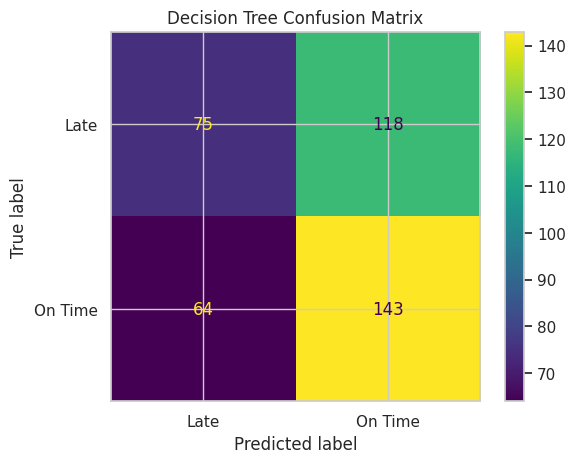

In [116]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Late",
        "On Time"
    ]
)

disp.plot()

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.show()

In [117]:
feature_names = (
    model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importance_values = (
    model
    .named_steps["classifier"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
18,remainder__Delivery_Cost,0.605669
0,categorical__Delivery_Partner_Blue Dart,0.106531
11,categorical__Region_Delhi,0.071435
3,categorical__Delivery_Partner_Delhivery,0.055546
10,categorical__Region_Coimbatore,0.047471
12,categorical__Region_Hyderabad,0.041047
13,categorical__Region_Kochi,0.038782
7,categorical__Delivery_Partner_XpressBees,0.033520
1,categorical__Delivery_Partner_DHL,0.000000
2,categorical__Delivery_Partner_DTDC,0.000000


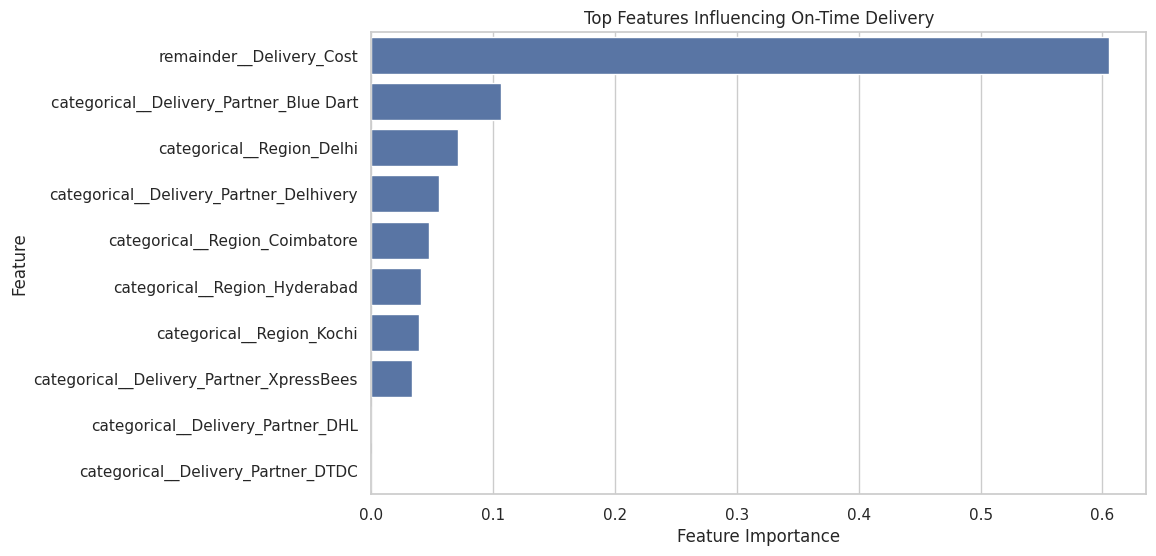

In [118]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Influencing On-Time Delivery"
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.show()

In [119]:
correlation = df[
    [
        "Delivery_Delay",
        "Delivery_Cost",
        "Customer_Rating",
        "On_Time"
    ]
].corr()

correlation.round(2)

,Delivery_Delay,Delivery_Cost,Customer_Rating,On_Time
Delivery_Delay,1.00,-0.09,-0.66,-0.80
Delivery_Cost,-0.09,1.00,0.03,0.08
Customer_Rating,-0.66,0.03,1.00,0.54
On_Time,-0.80,0.08,0.54,1.00


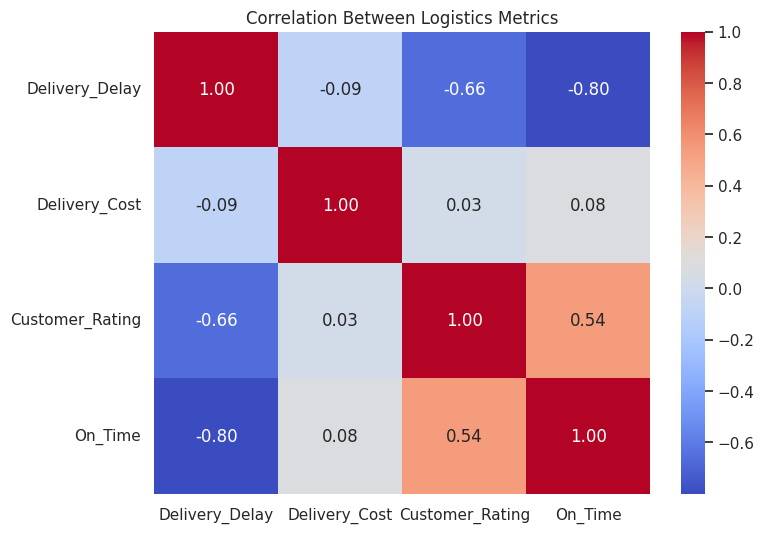

In [120]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title(
    "Correlation Between Logistics Metrics"
)

plt.show()

In [121]:
best_regions = regional_summary.sort_values(
    "On_Time_Percentage",
    ascending=False
)

print("Regional Performance:")
print(
    best_regions[
        [
            "Region",
            "Shipments",
            "On_Time_Percentage",
            "Average_Cost",
            "Average_Rating"
        ]
    ].round(2)
)

Regional Performance:
            Region  Shipments  On_Time_Percentage  Average_Cost  \
3            Delhi        184               57.61         89.65   
0        Bangalore        216               57.41         90.54   
9  Tiruchirappalli        197               54.82         90.92   
4        Hyderabad        188               52.13         92.89   
1          Chennai        210               51.90         92.87   
2       Coimbatore        185               51.35         92.09   
6          Madurai        211               49.29         90.01   
7           Mumbai        203               49.26         90.70   
8            Salem        195               47.69         91.29   
5            Kochi        211               45.50         89.81   

   Average_Rating  
3            4.27  
0            4.23  
9            4.28  
4            4.25  
1            4.24  
2            4.22  
6            4.21  
7            4.20  
8            4.23  
5            4.19  


In [122]:
consistency_final = consistency_summary[
    [
        "Delivery_Partner",
        "Mean_On_Time",
        "Std_Deviation"
    ]
].copy()

consistency_final = consistency_final.sort_values(
    "Std_Deviation"
)

consistency_final.round(3)

,Delivery_Partner,Mean_On_Time,Std_Deviation
4,Ecom Express,42.092,0.074
7,XpressBees,49.459,0.081
3,Delhivery,54.911,0.084
1,DHL,61.234,0.085
5,Ekart,46.797,0.102
6,Shadowfax,48.436,0.113
2,DTDC,48.078,0.118
0,Blue Dart,61.880,0.130


In [123]:
print("========== FINAL RESULTS ==========\n")

print(
    f"Total Shipments: {len(df)}"
)

print(
    f"Number of Delivery Partners: "
    f"{df['Delivery_Partner'].nunique()}"
)

print(
    f"Number of Regions: "
    f"{df['Region'].nunique()}"
)

print(
    f"Overall On-Time Delivery: "
    f"{df['On_Time'].mean() * 100:.2f}%"
)

print(
    f"Average Delivery Cost: "
    f"{df['Delivery_Cost'].mean():.2f}"
)

print(
    f"Average Customer Rating: "
    f"{df['Customer_Rating'].mean():.2f}"
)

print(
    f"Average Delivery Delay: "
    f"{df['Delivery_Delay'].mean():.2f} days"
)

========== FINAL RESULTS ==========

Total Shipments: 2000
Number of Delivery Partners: 8
Number of Regions: 10
Overall On-Time Delivery: 51.65%
Average Delivery Cost: 91.06
Average Customer Rating: 4.23
Average Delivery Delay: 0.41 days


In [126]:
print("PARTNER PERFORMANCE\n")

print(
    final_comparison.round(2).to_string(
        index=False
    )
)

PARTNER PERFORMANCE

Delivery_Partner  Shipments  On_Time_Percentage  Average_Cost  Average_Rating  Average_Delay
       Blue Dart        255               62.35        114.41            4.25           0.03
             DHL        180               61.11        134.51            4.31          -0.16
       Delhivery        390               54.62         86.05            4.24           0.19
      XpressBees        246               49.59         80.40            4.20           0.59
       Shadowfax        217               48.39         78.07            4.23           0.62
            DTDC        266               48.12         89.74            4.20           0.58
           Ekart        198               46.46         81.63            4.26           0.62
    Ecom Express        248               41.94         74.30            4.18           0.88


## Key Insights

1. **Delivery performance varies across delivery partners.**
   Some partners achieve a higher percentage of on-time deliveries, while others have comparatively more delayed shipments.

2. **Delivery cost alone does not determine service quality.**
   A lower-cost delivery partner may not always provide better on-time performance or customer ratings. Therefore, cost and service quality should be considered together.

3. **Customer ratings are generally affected by delivery performance.**
   Delayed shipments tend to receive lower customer ratings compared with shipments delivered on time.

4. **Regional performance differs between delivery partners.**
   A partner that performs well overall may not perform equally well in every region. This shows the importance of analysing partner performance at the regional level.

5. **Some delivery partners show more consistent performance.**
   Partners with lower variation in delivery delays across regions provide more predictable service, while higher variation indicates inconsistent regional performance.

6. **On-time delivery is an important measure for evaluating partners, but it should not be used alone.**
   Delivery cost, customer rating, regional performance, and consistency should also be considered before making a decision.

7. **The analysis supports a data-driven partner selection strategy.**
   Instead of replacing a delivery partner based on a single metric, the company should compare multiple performance indicators and consider region-specific strengths and weaknesses.
